In [ ]:
import math
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
from torchvision import datasets,transforms
import timm
import cv2
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RND = 42
random.seed(RND); np.random.seed(RND); torch.manual_seed(RND)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("sheikhzaib/sports-image-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sheikhzaib/sports-image-image-classification


In [ ]:
data_dir = "/kaggle/input/datasets/sheikhzaib/sports-image-image-classification/sports"
dataset = datasets.ImageFolder(root=data_dir)

print(len(dataset))

14160


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

widths = []
heights = []

# dataset.samples = list (path, label)
for path, _ in dataset.samples:
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except:
        continue

plt.figure(figsize=(6,6))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image size distribution")
plt.show()

In [ ]:
targets = np.array(dataset.targets)

train_idx, temp_idx = train_test_split(
    np.arange(len(dataset)),
    test_size=0.3,
    stratify=dataset.targets,
    random_state=RND
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=np.array(dataset.targets)[temp_idx],
    random_state=RND
)

train_set = Subset(datasets.ImageFolder(root=data_dir), train_idx)
val_set   = Subset(datasets.ImageFolder(root=data_dir), val_idx)
test_set  = Subset(datasets.ImageFolder(root=data_dir), test_idx)

train_labels = targets[train_idx]

In [ ]:
def get_labels(dataset):
    if hasattr(dataset, "targets"):
        return np.array(dataset.targets)

    elif hasattr(dataset, "dataset"):  # Subset
        return np.array(dataset.dataset.targets)[dataset.indices]

    else:
        raise ValueError("Dataset type not supported")

In [ ]:
def show_label_distribution(dataset, class_names=None, title='Label distribution'):
    labels = get_labels(dataset)
    # labels = dataset.targets

    counter = Counter(labels)
    sorted_items = sorted(counter.items(), key=lambda x: x[1], reverse=True)

    xs = [class_names[i] if class_names else str(i) for i, _ in sorted_items]
    ys = [count for _, count in sorted_items]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=xs, y=ys)
    plt.title(title)
    plt.xticks(rotation=45, fontsize=8, ha='right')
    plt.tight_layout(pad=2)
    plt.show()

def show_sample_grid(dataset, n=16, resize=None, class_names=None, seed=42):
    rows = int(math.sqrt(n))
    cols = rows

    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    axes = axes.flatten()

    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(dataset), size=n, replace=False)

    for ax, i in zip(axes, idxs):
        img, label = dataset[i]

        if isinstance(img, torch.Tensor):
            img = transforms.ToPILImage()(img)

        if resize:
            img = img.resize((resize, resize))

        ax.imshow(img)
        title = class_names[label] if class_names else str(label)
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def eda_report(train_set, val_set, test_set, class_names=None):
    print("SAMPLE TRAIN")
    show_sample_grid(val_set, n=16, class_names=class_names)

    print("\n--- TRAIN ---")
    show_label_distribution(train_set, class_names, "Train")

    print("\n--- VAL ---")
    show_label_distribution(val_set, class_names, "Validation")

    print("\n--- TEST ---")
    show_label_distribution(test_set, class_names, "Test")

In [ ]:
class_names = dataset.classes

eda_report(train_set, val_set, test_set, class_names)

In [ ]:
def build_transforms(img_size=224, transform=False):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if not transform:
        train_transform = transforms.Compose([
            transforms.Resize((img_size,img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
        val_transform = transforms.Compose([
            transforms.Resize((img_size,img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    else:
        train_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandAugment(num_ops=2, magnitude=5),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

        val_transform = transforms.Compose([
            transforms.Resize((img_size,img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

    return train_transform, val_transform

In [ ]:
from torch.utils.data import WeightedRandomSampler

def build_dataloaders(train_set, val_set, test_set, config):
    batch_size = config.get("batch_size", 64)
    num_workers = config.get("num_workers", 4)

    class_counts = np.bincount(train_labels)
    class_weights = 1. / class_counts

    sample_weights = class_weights[train_labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=True,
        sampler=sampler
    )

    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True,
    )

    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True,
    )

    return train_loader, val_loader, test_loader

In [ ]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    model.eval()

    start_time = time.time()
    with torch.no_grad():
        for images, labels in loader:  # test_loader là DataLoader của test_set
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    end_time = time.time()

    total_time = end_time - start_time

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_preds, all_labels, total_time

In [ ]:
def freeze_backbone(model):
    for param in model.parameters():
        param.requires_grad = False

    if hasattr(model, "get_classifier"):
        for param in model.get_classifier().parameters():
            param.requires_grad = True
    elif hasattr(model, "classifier"):
        if isinstance(model.classifier, torch.nn.Sequential):
            for param in model.classifier.parameters():
                param.requires_grad = True
        else:
            for param in model.classifier.parameters():
                param.requires_grad = True
    else:
        if hasattr(model, "head"):
            for param in model.head.parameters():
                param.requires_grad = True

In [ ]:
CONFIG = {
    'num_workers': 4,
    'size': 224,
    'model': 'mobilenetv3_large_100',
    'pretrained': True,
    'transform': True,
    'num_classes': 22,
    'freeze': True,
    'batch_size': 64,
    'epochs': 0,
    'lr': 1e-3
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

train_transform, val_transform = build_transforms(CONFIG['size'], CONFIG['transform'])

train_set.dataset.transform = train_transform
val_set.dataset.transform   = val_transform
test_set.dataset.transform  = val_transform

train_loader, val_loader, test_loader = build_dataloaders(
    train_set, val_set, test_set, CONFIG
)

model = timm.create_model(
    CONFIG['model'],
    pretrained=CONFIG['pretrained'],
    num_classes=CONFIG['num_classes'],
    drop_rate=0.0
)

model = model.to(device)

if CONFIG['freeze']:
    freeze_backbone(model)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['epochs']
)

criterion = nn.CrossEntropyLoss()

Device: cuda


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

In [ ]:
best_f1 = 0

for epoch in range(CONFIG['epochs']):
    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    print(f"Epoch {epoch}:")

    for idx, (images, labels) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

        if idx % 40 == 0: print(f'Train [{idx}][{len(train_loader)}]\t| Total Loss: {total_loss / total_samples}')

    train_loss = total_loss / total_samples
    train_acc = total_correct / total_samples

    all_preds, all_labels, _ = evaluate(model, val_loader, device)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"  Train Acc: {train_acc:.4f}")
    print(f"  Val   Acc: {val_acc:.4f}")
    print(f"  Val   F1 : {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pth")

    scheduler.step()

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))

all_preds, all_labels, total_time = evaluate(model, test_loader, device)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Test Acc: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Inference time: {total_time:.2f}")

Test Acc: 0.9218
Test Precision: 0.9226
Test Recall: 0.9218
Test F1-Score: 0.9217
Inference time: 10.74


In [ ]:
from thop import profile

model.eval()

dummy_input = torch.randn(1, 3, 224, 224).to(device)

macs, params = profile(model, inputs=(dummy_input, ))

print(f"Params: {params/1e6:.2f} M")
print(f"FLOPs: {macs*2/1e9:.2f} G")

Number of wrong samples: 166


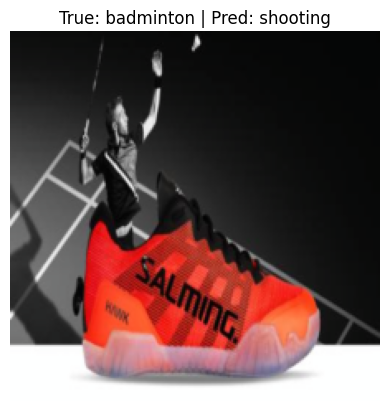

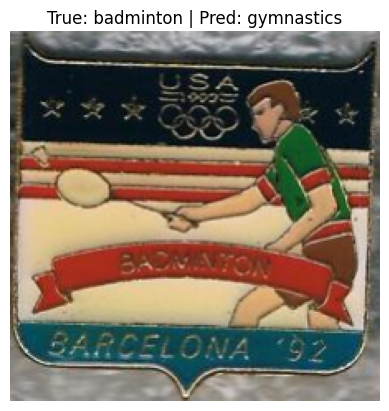

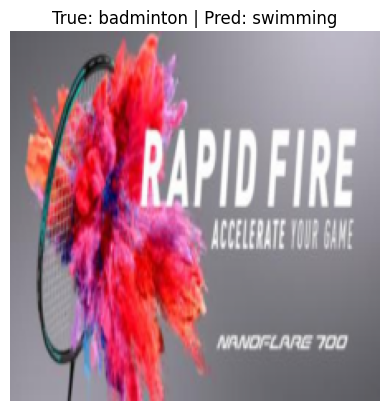

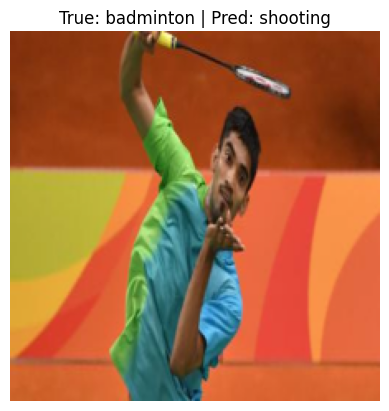

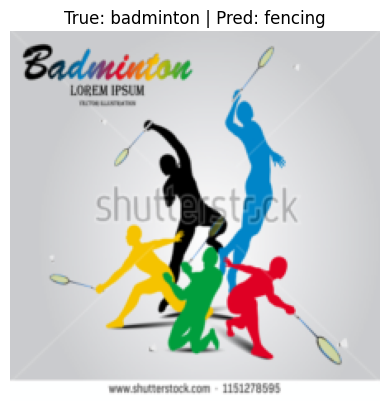

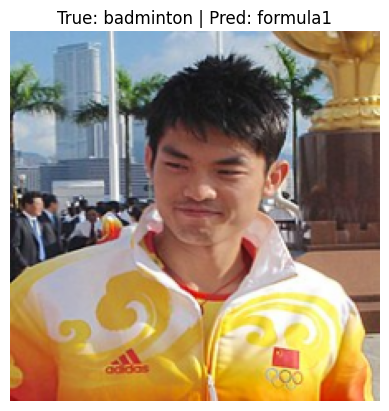

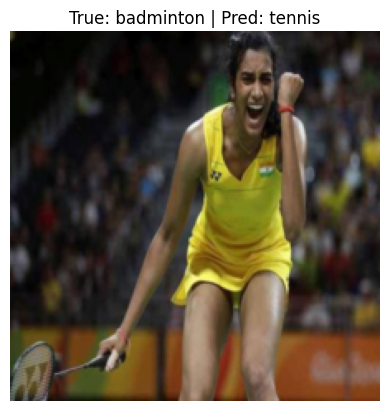

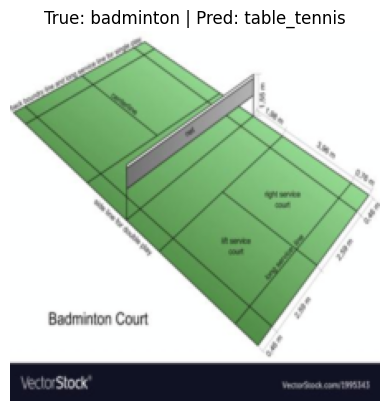

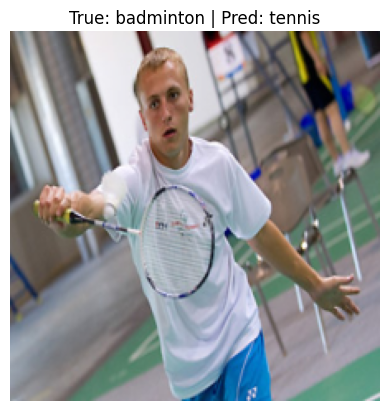

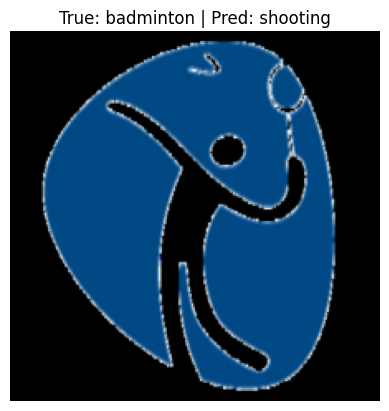

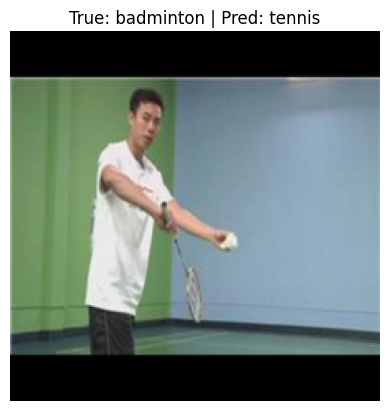

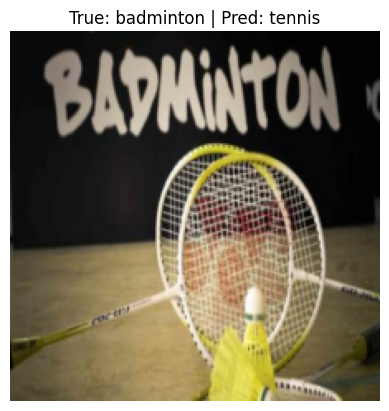

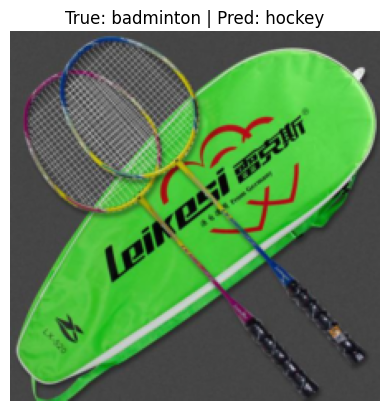

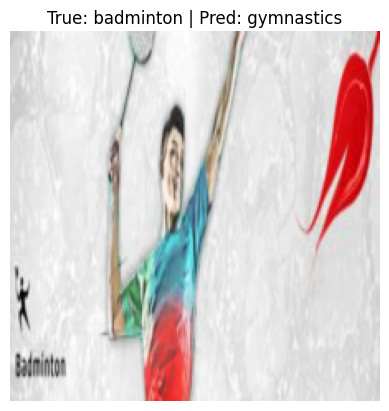

In [ ]:
wrong_indices = [i for i, (pred, label) in enumerate(zip(all_preds, all_labels)) if pred != label]
print(f"Number of wrong samples: {len(wrong_indices)}")

class_names = test_loader.dataset.dataset.classes

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

indices = []
for i in wrong_indices:
    img, label = test_loader.dataset[i]

    img = img.permute(1, 2, 0).cpu().numpy()

    img = img * std + mean
    img = np.clip(img, 0, 1)

    true_label = class_names[label]
    pred_label = class_names[all_preds[i]]

    if true_label == 'badminton':
        indices += [i]
        plt.imshow(img)
        plt.title(f"True: {true_label} | Pred: {pred_label}")
        plt.axis('off')
        plt.show()

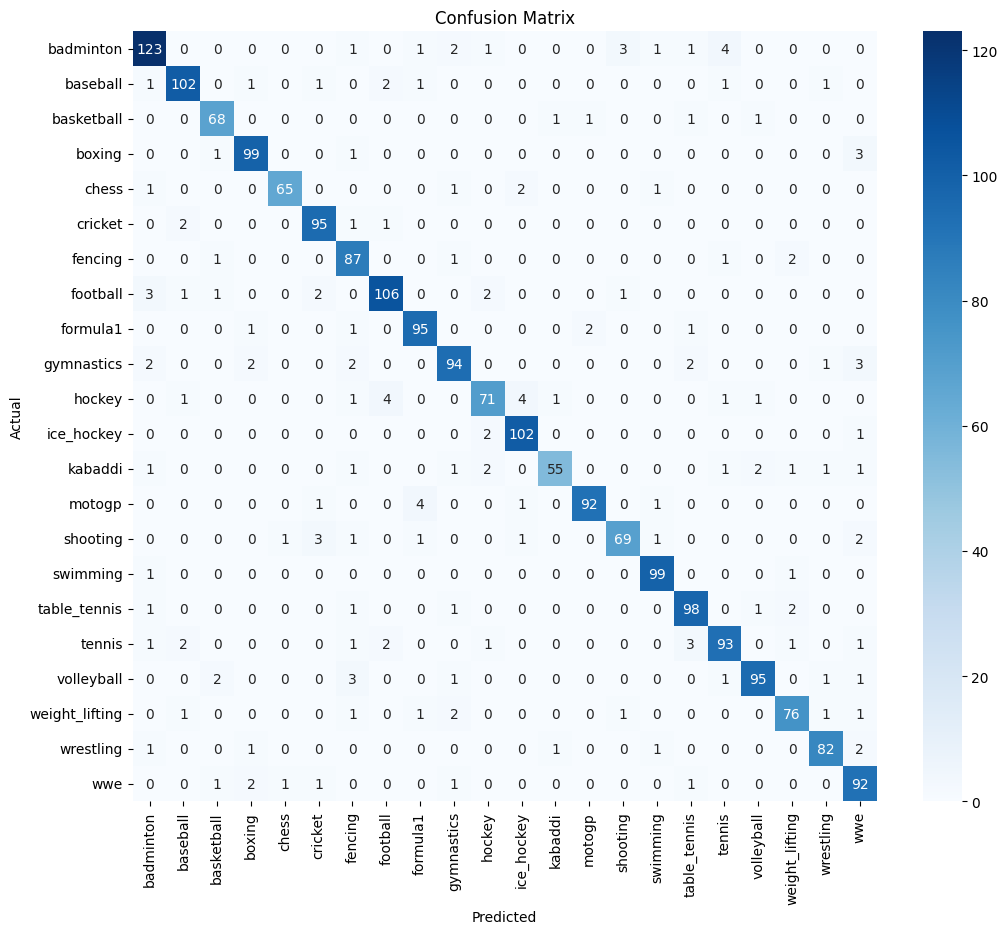

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

class_names = dataset.classes
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def unnormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = img * std + mean
    return np.clip(img, 0, 1)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1)

        loss = output[0, class_idx]
        loss.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)

        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

class AttentionRollout:
    def __init__(self, model):
        self.model = model
        self.attentions = []
        self._patch_attention()

    def _patch_attention(self):
        for block in self.model.blocks:
            attn_module = block.attn

            def forward_patch(x, attn_mask=None, **kwargs):
                B, N, C = x.shape

                qkv = attn_module.qkv(x)
                qkv = qkv.reshape(B, N, 3, attn_module.num_heads, C // attn_module.num_heads)
                qkv = qkv.permute(2, 0, 3, 1, 4)

                q, k, v = qkv[0], qkv[1], qkv[2]

                attn = (q @ k.transpose(-2, -1)) * attn_module.scale
                attn = attn.softmax(dim=-1)

                self.attentions.append(attn.detach())

                x = (attn @ v).transpose(1, 2).reshape(B, N, C)
                x = attn_module.proj(x)
                x = attn_module.proj_drop(x)

                return x

            attn_module.forward = forward_patch

    def __call__(self, x):
        self.attentions = []

        with torch.no_grad():
            self.model(x)

        B, H, N, _ = self.attentions[0].shape
        device = x.device

        result = torch.eye(N).to(device).unsqueeze(0).repeat(B, 1, 1)

        for attn in self.attentions:
            attn = attn.mean(dim=1)  # fuse heads
            attn = attn / attn.sum(dim=-1, keepdim=True)
            result = torch.bmm(attn, result)

        mask = result[:, 0, 1:]  # bỏ CLS

        num_tokens = mask.shape[-1]
        size = int(np.sqrt(num_tokens))

        mask = mask[:, :size * size]
        mask = mask.reshape(B, size, size)

        mask = mask.cpu().numpy()
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

        return mask

def show_cam_on_image(img, mask, title="Visualization"):
    mask_resized = cv2.resize(mask, (img.shape[1], img.shape[0]))
    heatmap = plt.cm.jet(mask_resized)[:, :, :3]

    cam_img = 0.4 * heatmap + 0.6 * img
    cam_img = cam_img / cam_img.max()

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cam_img)
    plt.title(title)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

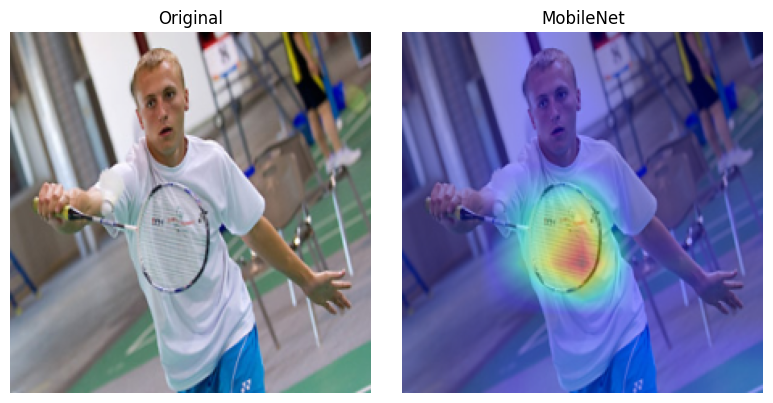

In [ ]:
wrong_image_idx = indices[0]
image, label = test_loader.dataset[wrong_image_idx]

x = image.unsqueeze(0).to(device)
x.requires_grad_(True)
img_display = unnormalize(image)

if 'resnet' in CONFIG["model"].lower():
    target_layer = model.layer4[-1]

    grad_cam = GradCAM(model, target_layer)
    mask = grad_cam(x)

    show_cam_on_image(img_display, mask, title="ResNet50")

elif 'vit' in CONFIG["model"].lower():
    rollout = AttentionRollout(model)

    mask = rollout(x)[0]

    show_cam_on_image(img_display, mask, title="ViT")

elif 'mobile' in CONFIG["model"].lower():
    target_layer = model.blocks[-1]

    grad_cam = GradCAM(model, target_layer)
    mask = grad_cam(x)

    show_cam_on_image(img_display, mask, title="MobileNet")

In [ ]:
import torch
import numpy as np

@torch.no_grad()
def get_probs_and_labels(model, loader, device):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_probs, all_labels

def compute_ece(probs, labels, n_bins=15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)

    accuracies = (predictions == labels)

    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])

        if np.sum(mask) > 0:
            acc = np.mean(accuracies[mask])
            conf = np.mean(confidences[mask])
            ece += np.abs(acc - conf) * np.sum(mask) / len(labels)

    return ece

import matplotlib.pyplot as plt

def plot_reliability_diagram(probs, labels, n_bins=15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)

    accuracies = (predictions == labels)

    bins = np.linspace(0, 1, n_bins + 1)

    bin_acc = []
    bin_conf = []

    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])

        if np.sum(mask) > 0:
            bin_acc.append(np.mean(accuracies[mask]))
            bin_conf.append(np.mean(confidences[mask]))
        else:
            bin_acc.append(0)
            bin_conf.append(0)

    plt.figure()
    plt.plot(bin_conf, bin_acc, marker='o')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability Diagram")
    plt.show()

probs, labels = get_probs_and_labels(model, test_loader, device)
ece = compute_ece(probs, labels)
plot_reliability_diagram(probs, labels)
print(f"Model ECE: {ece:.4f}")